In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

# load all utils functions
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from model_utils import *
from data_utils import *
from dataloader import MtbGeneDataset
from inSilicoMut_utils import *

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
# df_mxf = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")
df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

2023-02-21 12:35:13.291439: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-02-21 12:35:13.480594: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-02-21 12:35:13.480638: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-02-21 12:35:14.739450: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-

# Introduce Compatible Mutations from the WHO V1 Catalog into H37Rv and Predict with Model

## Focus on rpoB first, then move on to other genes

In [2]:
# sequence dataframe
rpoBC_seqDF = pd.read_csv("Rifampicin/rpoBC_saliency_seqdf.csv").set_index("Isolate")
rpoBC_seqDF.columns = [int(float(col)) if "." in col else col for col in rpoBC_seqDF.columns]

rif_rpoBC_df = pd.read_csv("Rifampicin/rpoBC_saliency_results.csv")

for i, row in rif_rpoBC_df.iterrows():
    if ".0" in row["Pos"]:
        rif_rpoBC_df.loc[i, "Pos"] = int(row["Pos"].replace(".0", ""))
        
        
# get dictionaries mapping WHO categories to unique sites and dataframes
rpoB_sites_dict, rpoB_dfs_dict = get_dict_WHO_mutations_sites(who_variants, "RIF", "rpoB")

# all rpoB mutations merged with the saliency dataframe
rpoB_ALL = pd.concat([rpoB_dfs_dict[num] for num in range(1, 6)], axis=0)
print(rpoB_ALL.shape)

(781, 4)


# Write Variants to Synthetic VCF Files and Save a txt file of them

## Both of these components are needed to run <code>04_make_MSA.py</code>

In [3]:
rpoB_ALL = get_data_for_synthetic_VCF(rpoB_ALL, "pos")

# all sites in rpoB, rpoB_for_VCF = all WHO rpoB variants
print(rif_rpoBC_df.shape, rpoB_ALL.shape)

# merge with the saliency dataframe to get only WHO mutations THAT WERE ALSO IN OUR MODEL (biggest difference is upstream nucleotides, WHO included more)
rpoB_ALL = rpoB_ALL.merge(rif_rpoBC_df, left_on="POS", right_on="Pos", how="inner")

# keep only sites in our alignment
rpoB_ALL = rpoB_ALL.query("POS >= 759611 & POS <= 767320")
print(rpoB_ALL.shape)

(7814, 9) (781, 9)
(750, 18)


In [4]:
insertion_df_old = pd.DataFrame({"idx": [27, 37, 226, 753, 1486, 1488, 1491, 1495, 1704, 2202, 2741, 2820, 3717, 4750, 5636, 6881, 6884, 7002, 7063],
                                 "len_insertion": [1, 21, 6, 12, 3, 3, 3, 3, 3, 3, 6, 3, 1, 3, 3, 3, 15, 6, 6]
                                })

insertion_df = pd.DataFrame({"idx": [12, 27, 31, 37, 45, 75, 116, 137, 226, 489, 753, 1486, 1488, 1491, 1495, 1523, 1524, 1698, 1704, 1719, 2202, 2741, 2757, 2820, 3712, 3717, 4750, 5636, 6881, 6884, 7002, 7063],
                             "len_insertion": [21, 1, 1, 21, 2, 1, 2, 1, 6, 6, 12, 3, 3, 3, 3, 3, 3, 9, 3, 18, 3, 6, 6, 3, 1, 1, 3, 3, 3, 15, 6, 6]
                            })

insertion_df_old["name"] = "old"
insertion_df["name"] = "new"

insertions_combined = insertion_df_old.merge(insertion_df, on="idx", how="outer")

# idx + START + 1 = record.POS
insertions_combined["POS"] = insertions_combined["idx"] + 759610 + 1

In [5]:
# x = old, y = new
search_df = insertions_combined.loc[pd.isnull(insertions_combined["name_x"])]
print(search_df["len_insertion_y"].sum())
search_df[["idx", "POS", "len_insertion_y"]]

74


,idx,POS,len_insertion_y
19,12,759623,21
20,31,759642,1
21,45,759656,2
22,75,759686,1
23,116,759727,2
24,137,759748,1
25,489,760100,6
26,1523,761134,3
27,1524,761135,3
28,1698,761309,9


In [6]:
# 7885 vs. 7814 --> need to remove 71 nucleotides?
rpoB_ALL["REF_len"] = [len(val) for val in rpoB_ALL["REF"]]
rpoB_ALL["ALT_len"] = [len(val) for val in rpoB_ALL["ALT"]]

drop_mutations = rpoB_ALL.query("POS in @search_df.POS & ALT_len > REF_len")[["confidence", "mutation", "POS", "REF", "ALT"]].mutation.values
drop_mutations = np.append(drop_mutations, 'rpoB_p.Pro15_Ser16insSerPro')
print(f"Dropped {len(drop_mutations)} mutations to preserve the alignment")

rpoB_ALL_VCF = rpoB_ALL.query("mutation not in @drop_mutations")
print(rpoB_ALL_VCF.shape, len(rpoB_ALL_VCF.mutation.unique()))

Dropped 13 mutations to preserve the alignment
(737, 20) 711


In [7]:
# # then write them to new VCF files
# create_synthetic_VCF_files(rpoB_ALL_VCF, 
#                            "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoB_WHO_mutations.txt", 
#                            vcf_dir
#                           )

In [8]:
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"
count = 0
for fName in os.listdir(vcf_dir):
    if "rpoB" in fName:
        #os.remove(os.path.join(vcf_dir, fName))
        count += 1
count

711

In [9]:
print(f"{len(rpoB_ALL_VCF.mutation.unique())} rpoB mutations across {len(rpoB_ALL_VCF['POS'].unique())} sites")

if "Pos" in rpoB_ALL_VCF.columns:
    if len(rpoB_ALL_VCF.query("POS != Pos")) == 0:
        del rpoB_ALL_VCF["Pos"]

711 rpoB mutations across 591 sites


# Predict MICs for Synthetic Sequences (single mutations inserted into H37Rv)

In [10]:
locus_list = ["rpoBC"]

# argument = directory that contains the fasta file
df_genos = make_genotype_df(locus_list, "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis")

# the additional new strains to predict MICs for
keep_strains = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoB_WHO_mutations.txt", sep="\t", header=None)[0].values
df_genos = df_genos.loc[keep_strains]

# Apply one-hot encoding function to get each isolate sequence
print('making one hot encoding for...')
for locus in locus_list:
    print("...", locus)
    lengths = [len(seq) for seq in df_genos[locus]]
    assert len(np.unique(lengths)) == 1
    df_genos[locus + "_one_hot"] = df_genos[locus].apply(np.vectorize(get_one_hot))
    
X = create_X(df_genos)
print(X.shape)

1 loci!
reading fasta file /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoBC.fasta
making one hot encoding for...
... rpoBC
found 1 genes and longest gene 7814
(711, 5, 7814, 1)


In [11]:
# load in saved best model (NO LINEAGES BECAUSE IT WASN'T SIGNIFICANT FOR RIFAMPICIN)
config_file = "../config_rif.yaml"
kwargs = yaml.safe_load(open(config_file, "r"))

drug = kwargs["drug"]
locus_list = kwargs["locus_list"]
filter_size = kwargs["filter_size"]
BATCH_SIZE = kwargs["batch_size"]
N_epochs = kwargs["N_epochs"]
patience_epochs = kwargs["patience_epochs"]

output_path = kwargs["output_path"]
phenotype_file = kwargs["phenotype_file"]
genotype_input_directory = kwargs["genotype_input_directory"]
binary_thresh = kwargs["binary_thresh"]
include_lineage = kwargs["include_lineage"]
loss_type = kwargs["loss_type"]
binary = False
bounded_loss = True

num_loci = len(locus_list)
df_phenos = pd.read_csv(phenotype_file)

# get longest locus from the pickle file
X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz'))

# shape = 1 x 5 x longest_locus x num_loci
longest_locus = X_h37rv.shape[2]
del X_h37rv

if include_lineage:
    num_lineages = train_generator[0][0][1].shape[1]
else:
    num_lineages = 0

best_model = conv_nn(binary, longest_locus, num_loci, num_lineages, bounded_loss, filter_size)
best_model.load_weights(os.path.join(output_path, "best_model.h5"))

# X and df_genos are in the same order because df_genos is passed in as an argument to the function to make X
predicted_mics = best_model.predict([X, np.zeros(X.shape[0]), np.zeros(X.shape[0])]).flatten()

# add to the dataframe
df_genos["MIC_pred"] = predicted_mics

df_genos = df_genos[["MIC_pred"]].reset_index().rename(columns={"index":"mutation"})
df_genos = df_genos.merge(who_variants.query("drug=='RIF'"), on="mutation", how="inner")

2023-02-21 12:39:05.237535: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2023-02-21 12:39:05.237585: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2023-02-21 12:39:05.237621: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (compute-e-16-239.o2.rc.hms.harvard.edu): /proc/driver/nvidia/version does not exist
2023-02-21 12:39:05.237997: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Fitting quantitative model
23/23 [==============================] - 13s 567ms/step


In [12]:
def combine_score_across_multiple_sites(saliency_df, multi_site_str):

    split_sites = multi_site_str.split(",")
    sig_score_sites = []

    for site in split_sites:

        site = int(site)
        if len(saliency_df.query("POS==@site & Max_Sig == 1")) > 0:
            max_score = saliency_df.query("POS==@site & Max_Sig == 1").Max.values[0]
        else:
            max_score = None

        if len(saliency_df.query("POS==@site & Min_Sig == 1")) > 0:
            min_score = saliency_df.query("POS==@site & Min_Sig == 1").Min.values[0]
        else:
            min_score = None

        # take the largest magnitude score at each site
        if max_score is not None:
            if min_score is not None:
                if max_score > -min_score:
                    sig_score_sites.append(max_score)
                else:
                    sig_score_sites.append(min_score)
            else:
                sig_score_sites.append(max_score)
        else:
            if min_score is not None:
                sig_score_sites.append(min_score)
            else:
                sig_score_sites.append(0)
                
    return np.mean(sig_score_sites)

In [13]:
def add_saliency_scores(plot_df):
    
    for i, row in plot_df.iterrows():

        if len(row["REF"]) > 1 or len(row["ALT"]) > 1:

            pos = row["POS"]
            search_idx = rif_rpoBC_df.query("Pos==@pos").index.values[0]
            diff_len = np.abs(len(row["REF"]) - len(row["ALT"]))

            max_sig_df = rif_rpoBC_df.iloc[search_idx:search_idx+diff_len].query("Max_Sig==1")
            if len(max_sig_df) > 0:
                max_score = np.max(max_sig_df["Max"])
            else:
                max_score = 0

            min_sig_df = rif_rpoBC_df.iloc[search_idx:search_idx+diff_len].query("Min_Sig==1")
            if len(min_sig_df) > 0:
                min_score = np.min(min_sig_df["Min"])
            else:
                min_score = 0

            # if max_score > -min_score:
            #     plot_df.loc[i, "saliency_score"] = max_score
            # else:
            #     plot_df.loc[i, "saliency_score"] = min_score
            plot_df.loc[i, "saliency_score"] = np.mean([max_score, min_score])

        else:
            if "," in row["genome_index"]:
                plot_df.loc[i, "saliency_score"] = combine_score_across_multiple_sites(plot_df, row["genome_index"])
            else:
                if row["Max_Sig"] == 1 and row["Min_Sig"] == 0:
                    plot_df.loc[i, "saliency_score"] = row["Max"]

                elif row["Max_Sig"] == 0 and row["Min_Sig"] == 1:
                    plot_df.loc[i, "saliency_score"] = row["Min"]

                elif row["Max_Sig"] == 1 and row["Min_Sig"] == 1:

                    # take the one with the larger magnitude
                    if row["Max"] > -row["Min"]:
                        plot_df.loc[i, "saliency_score"] = row["Max"]
                    else:
                        plot_df.loc[i, "saliency_score"]  = row["Min"]

                else:
                    plot_df.loc[i, "saliency_score"] = 0
                            
    # if a mutation requires more than one SNV, then there will be multiple rows. But the saliency scores have now been combined, so drop the duplicates 
    # (they will have the same value in the saliency_score field)
    plot_df = plot_df.drop_duplicates("mutation", keep="first").reset_index(drop=True)

    # nothing should be NaN anywhere in the dataframe
    assert len(plot_df.dropna()) == len(plot_df)
    print(plot_df.shape)
    
    return plot_df

In [14]:
plot_df = df_genos[["mutation", "MIC_pred", "genome_index"]].merge(rpoB_ALL_VCF, on="mutation", how="outer").reset_index(drop=True)

del_cols = ["saliency_score", "drug", "WHO", "Lineage_SNP"]

for col in del_cols:
    if col in plot_df.columns:
        del plot_df[col]
        
print(plot_df.shape)

plot_df = add_saliency_scores(plot_df)
print(plot_df.shape)

(737, 18)
(711, 19)
(711, 19)


# Get all Positions with Mutations from the Training Dataset to Compare to the WHO Catalog

The point of this is to check only the saliencies for positions where we actually have mutations in our dataset.

We wouldn't expect significant non-zero saliency scores elsewhere because the model only saw reference calls at those sites.

### BUT, we still want the model to be able to predict reasonably well on sequences containing mutations it hasn't seen before

### We just don't expect the saliency scores to reflect that

In [18]:
# list of VCF files in our dataset 
files_lst = pd.read_csv("RIF_vcf_files.txt", sep="\t", header=None)[0].values
print(f"{len(files_lst)} VCF files of variants")

# extract the mutations in the region of interest (rpoB only here), then write them to a new directory
# the files in /n/scratch3/users/s/sak0914/annotated_VCF are all non-reference calls from the training dataset
# the new directory will contain all non-reference calls, but only in the region of interest

# /home/sak0914/MtbQuantCNN/analysis/RIF_vcf_files.txt /n/scratch3/users/s/sak0914/RIF_rpoBC_VCF
# cat "$1" | while read vcf_file; do
    
#     # remove the full path
#     fName=$(basename $vcf_file)

#     # remove the part after the underscore, which leaves only the isolate name remaining
#     isolate=${fName%_*}
    
#     # check if the filtered VCF file does not exist. If it doesn't, filter and create it
#     if [ ! -f "$2/$isolate" ]; then
    
#         # filter the VCF file: keep all variants and all FILTER tags. This step just removes reference calls
#         bcftools query -i 'POS >= 759611 & POS <= 767320' -f '%CHROM\t%POS\t%REF\t%ALT\t%QUAL\t%FILTER\t%AF\n' "$vcf_file" > "$2/$isolate" 
#     else
#         echo "$2/$isolate exists"
#     fi
# done

9670 VCF files of variants


## Next, combine the non-reference rpoB variant calls into a single dataframe to extract all rpoB positions that have a non-REF allele

In [19]:
isolates_var_dir = "/n/scratch3/users/s/sak0914/RIF_rpoBC_VCF"
rpoBC_variants = pd.DataFrame(columns=["Sample", "CHROM", "POS", "REF", "ALT", "QUAL", "FILTER", "AF"])
empty_files = 0

for fName in os.listdir(isolates_var_dir):
    
    isolate = os.path.basename(fName).split(".")[0]
    
    if isolate in df_rif["ROLLINGDB_ID"].values:
    
        # check if the file is not empty (empty means no variants in rpoBC, all ref alleles)
        if not os.stat(os.path.join(isolates_var_dir, fName)).st_size == 0:
            df = pd.read_csv(os.path.join(isolates_var_dir, fName), sep="\t", header=None)
            df.columns = ["CHROM", "POS", "REF", "ALT", "QUAL", "FILTER", "AF"]
            df["Sample"] = isolate
            
            rpoBC_variants = pd.concat([rpoBC_variants, df], axis=0)
        else:
            # print(f"{os.path.join(isolates_var_dir, fName)} is empty")
            empty_files += 1

In [20]:
# these are the positions in the WHO catalog AND in our dataset -- these are the sites that we expect the saliency scores to correlate with predicted MICs for a given mutation
overlap_pos = list(set(plot_df["POS"]).intersection(rpoBC_variants["POS"]))
len(overlap_pos)

291

In [21]:
for i, row in plot_df.iterrows():
    
    pos = row["POS"]
    
    if pos in overlap_pos:
        if row["REF"] in rpoBC_variants.query("POS==@pos")["REF"].values and row["ALT"] in rpoBC_variants.query("POS==@pos")["ALT"].values:
            plot_df.loc[i, "dataset"] = 1
    
plot_df["dataset"] = plot_df["dataset"].fillna(0).astype(int)

pd.DataFrame(plot_df.groupby(["confidence", "dataset"])["dataset"].count()).rename(columns={"dataset":"count"})

count
confidence                dataset       
1) Assoc w R              1           23
2) Assoc w R - Interim    0           36
                          1           57
3) Uncertain significance 0          337
                          1          250
5) Not assoc w R          0            4
                          1            4

In [22]:
pd.DataFrame(plot_df.groupby(["confidence"])["MIC_pred"].mean())

,MIC_pred
confidence,
1) Assoc w R,1.463876
2) Assoc w R - Interim,-0.838426
3) Uncertain significance,-2.873960
5) Not assoc w R,-2.901617


# Plot Distribution of Predicted MICs

In [69]:
def plot_ECDF(df, saveName=None):
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.ecdfplot(data=df, x="MIC_pred", hue="confidence", palette="colorblind", ax=ax)
    # ax.get_legend().remove()

    ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp(ax.get_xticks()), 2).astype(str))
    plt.xlabel("Predicted MIC (µg/mL)")
    plt.title(f"ECDFs of MICs Predicted for {len(df)} WHO Mutations")
    
    y = df["MIC_pred"]
    plt.xlim(y.min()*1.1, y.max()*1.1)

    # fig.legend(labels=df["confidence"].unique())
    sns.move_legend(ax, fontsize=8, title='', loc='upper right', bbox_to_anchor=(1.5, 0.6))
    # ax.legend(loc='center right', bbox_to_anchor=(1.0, 1.0), fontsize=4, title='')
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

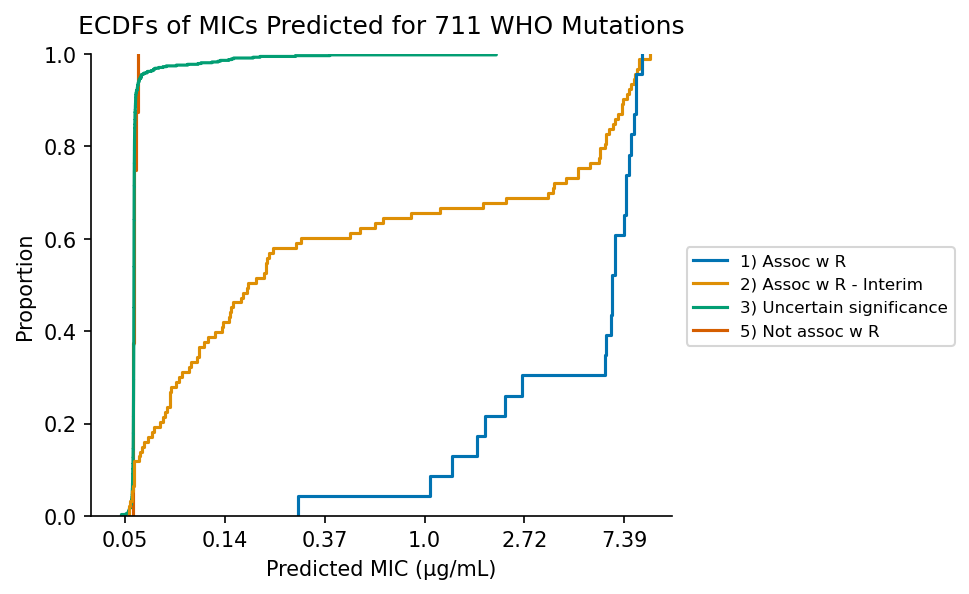

In [70]:
plot_ECDF(plot_df, "../figures/insilicoMut/rpoB_MIC_ECDF_allMut.png")

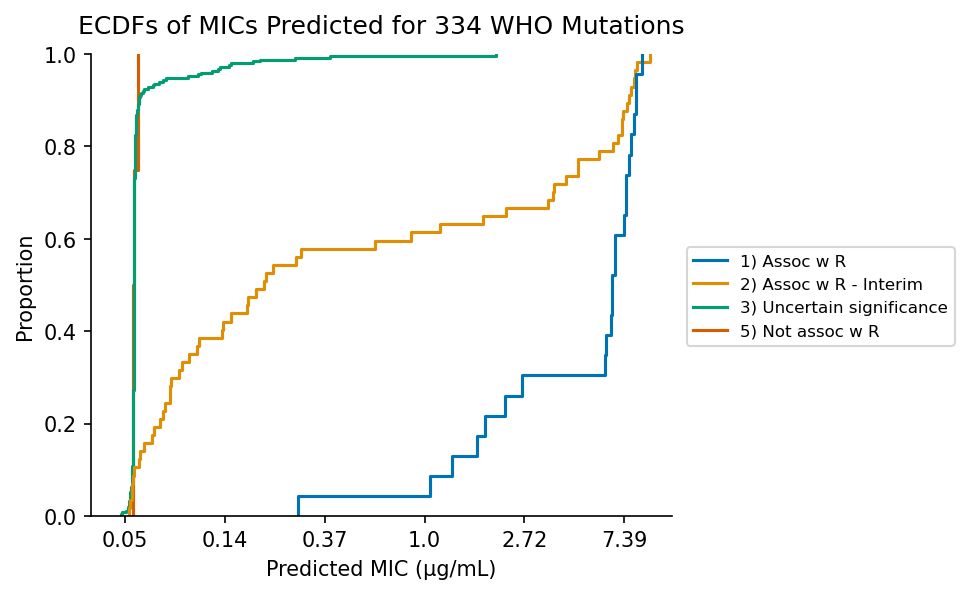

In [71]:
plot_ECDF(plot_df.query("dataset==1"))

# Correlation Between Predicted MIC and Saliency Scores for Mutation IN the Training Dataset

In [73]:
def perform_correlation_permutation_test(x, y, corr_func, num_reps=1000):
    
    # 1. Shuffle data pairs
    # 2. Compute correlation coefficient R on the shuffled set
    # 3. Repeat N times and see how many times the permuted Rs are as extreme as the true value

    true_val = corr_func(x, y)[0]
    permuted_corrs = []
    
    for _ in range(num_reps):
        y_permute = y.copy()
        np.random.shuffle(y_permute)
        permuted_corrs.append(corr_func(x, y_permute)[0])
    
    if true_val > 0:
        return true_val, permuted_corrs, np.mean(permuted_corrs > true_val)
    else:
        return true_val, permuted_corrs, np.mean(permuted_corrs < true_val)

In [94]:
def saliency_scatter_plot(df, saveName=None):
    
    fig, ax = plt.subplots()
    sns.scatterplot(data=df, x="saliency_score", y="MIC_pred", hue="confidence", s=35, edgecolors="black", linewidths=0.5, alpha=0.7, palette="colorblind", ax=ax)

    x = df["saliency_score"].values
    y = df["MIC_pred"].values
    
    corr, permuted_corrs, pval = perform_correlation_permutation_test(x, y, st.pearsonr)

    plt.title(f"{len(df)} rpoB WHO Mutations\nPearson R = {np.round(corr, 2)}, p-value = {pval}")
    plt.axhline(y=np.log(0.5), color="black", linestyle="dashed", linewidth=1, label="CC = 0.5 µg/mL")
    plt.xlabel("Mutation Saliency Score")

    ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(np.exp(ax.get_yticks()), 2).astype(str))
    plt.ylabel("Predicted MIC (µg/mL)")
    plt.ylim(y.min()*1.1, y.max()*1.1)

    ax.legend(bbox_to_anchor=(1, 1))
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300)
    else:
        plt.show()

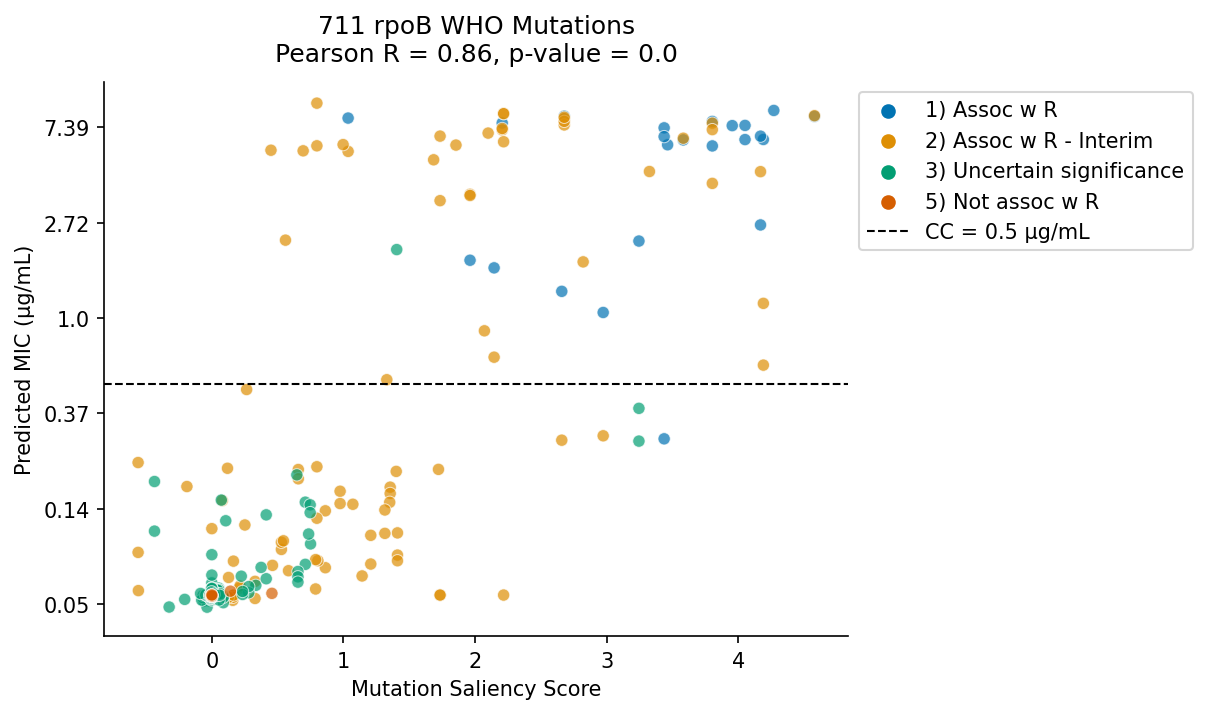

In [95]:
saliency_scatter_plot(plot_df)

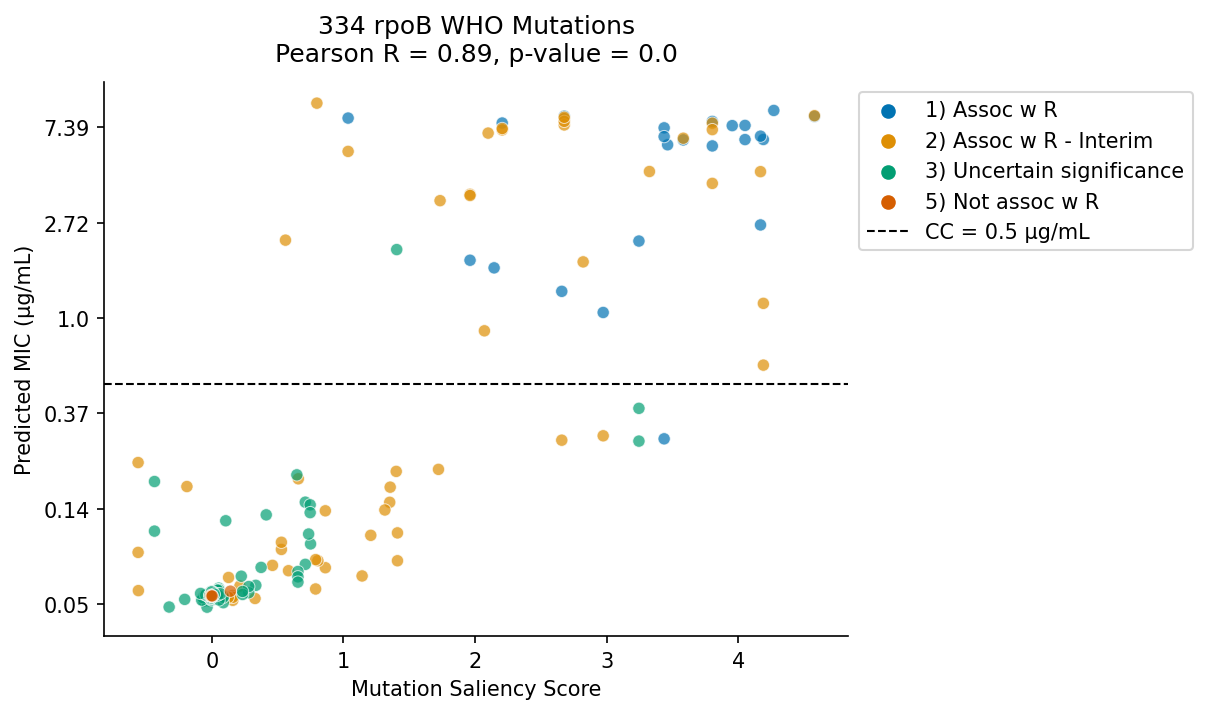

In [96]:
saliency_scatter_plot(plot_df.query("dataset==1"))

In [97]:
# uncertain mutation that predicts resistance
thresh = np.log(0.5)
plot_df.query("MIC_pred > @thresh and confidence.str.contains('3')")

,mutation,MIC_pred,genome_index,WHO_genome_index,confidence,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,REF_len,ALT_len,saliency_score,dataset
25,rpoB_p.Ile491Tyr,0.717621,"761277,761278",761277,3) Uncertain significance,761277,rpoB,p.Ile491Tyr,A,T,rpoBC,3.245414,0.0,0.008456,1.0,0.0,1,1,1.404827,1


In [93]:
thresh = np.log(0.5)
plot_df.query("dataset==1 & saliency_score > 2 & MIC_pred < @thresh")

,mutation,MIC_pred,genome_index,WHO_genome_index,confidence,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,REF_len,ALT_len,saliency_score,dataset
14,rpoB_p.His445Asn,-1.266834,761139,761139,1) Assoc w R,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.000000,0.103309,1.0,0.0,1,1,3.437077,1
23,rpoB_p.Ile491Val,-1.291064,761277,761277,3) Uncertain significance,761277,rpoB,p.Ile491Val,A,G,rpoBC,3.245414,0.000000,0.008456,1.0,0.0,1,1,3.245414,1
24,rpoB_p.Ile491Leu,-0.947316,761277,761277,3) Uncertain significance,761277,rpoB,p.Ile491Leu,A,C,rpoBC,3.245414,0.000000,0.008456,1.0,0.0,1,1,3.245414,1
33,rpoB_p.Asp435His,-1.235075,761109,761109,2) Assoc w R - Interim,761109,rpoB,p.Asp435His,G,C,rpoBC,2.973908,-0.722329,0.037628,1.0,1.0,1,1,2.973908,1
47,rpoB_p.Leu430Arg,-1.281270,761095,761095,2) Assoc w R - Interim,761095,rpoB,p.Leu430Arg,T,G,rpoBC,2.659062,0.000000,0.015638,1.0,0.0,1,1,2.659062,1


# Further Investigation of the Group 2 Mutations with Low Saliency Scores or Low Predicted MICs

### Hypothesis: Low saliency = not in the training dataset.
### Low predicted MIC: IDK!


761134 is the only (1/11) category 1 site without a significant positive saliency score in the RIF CNN

In [231]:
plot_df.query("dataset==1 & MIC_pred < @thresh & saliency_score > 2 & confidence.str.contains('|'.join(['1', '2']))")

,mutation,MIC_pred,genome_index,WHO_genome_index,confidence,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,REF_len,ALT_len,saliency_score,dataset
10,rpoB_p.Gln432His,-1.063436,761102,761102,2) Assoc w R - Interim,761102,rpoB,p.Gln432His,A,T,rpoBC,2.071347,0.000000,0.001046,1.0,0.0,1,1,2.071347,1
14,rpoB_p.His445Asn,-1.661120,761139,761139,1) Assoc w R,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.000000,0.103309,1.0,0.0,1,1,3.437077,1
29,rpoB_p.Asp435Ala,-0.963358,761110,761110,2) Assoc w R - Interim,761110,rpoB,p.Asp435Ala,A,C,rpoBC,4.191139,0.000000,0.223620,1.0,0.0,1,1,4.191139,1
33,rpoB_p.Asp435His,-1.884073,761109,761109,2) Assoc w R - Interim,761109,rpoB,p.Asp435His,G,C,rpoBC,2.973908,-0.722329,0.037628,1.0,1.0,1,1,2.973908,1
47,rpoB_p.Leu430Arg,-1.703787,761095,761095,2) Assoc w R - Interim,761095,rpoB,p.Leu430Arg,T,G,rpoBC,2.659062,0.000000,0.015638,1.0,0.0,1,1,2.659062,1


In [232]:
search_df = plot_df.query("MIC_pred < @thresh & saliency_score > 2 & confidence.str.contains('|'.join(['1', '2']))")
print(search_df.shape)
search_df = search_df[(search_df["REF"].apply(lambda x: len(x) == 1)) & (search_df["ALT"].apply(lambda x: len(x) == 1))]
print(search_df.shape)

(7, 20)
(6, 20)


In [233]:
scores = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz").todense()
# num_samples x 5 nucleotides x longest_locus x num_loci
scores.shape

(7480, 5, 7814, 1)

In [234]:
rif_rpoBC_df = rif_rpoBC_df.reset_index(drop=True)
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

def plot_nuc_scores_single_pos(pos):
    
    search_idx = rif_rpoBC_df.query("Pos==@pos").index.values[0]
    ref = plot_df.query("POS==@pos")["REF"].unique()[0]

    if rif_rpoBC_df.query("Pos==@pos")["Max_Sig"].values[0] == 1:
        scores_by_nuc = dict(zip(BASE_TO_COLUMN.keys(), np.max(scores[:, :, search_idx, :], axis=0).flatten()))

    elif rif_rpoBC_df.query("Pos==@pos")["Min_Sig"].values[0] == 1:
        scores_by_nuc = dict(zip(BASE_TO_COLUMN.keys(), np.min(scores[:, :, search_idx, :], axis=0).flatten()))

    else:
        raise ValueError(f"{pos} does not have a significant score!")

    plot_df_single_site = plot_df.query("POS==@pos")[["mutation", "MIC_pred", "ALT"]]
    y_col = "MIC_pred"
    
#     plot_df_single_site = rpoBC_seqDF[["Isolate", pos]]
#     plot_df_single_site = plot_df_single_site.merge(df_rif[["ROLLINGDB_ID", "RIF_midpoint"]], left_on="Isolate", right_on="ROLLINGDB_ID", how="inner")

#     plot_df_single_site = pd.DataFrame(plot_df_single_site.groupby(pos)["RIF_midpoint"].mean()).reset_index().rename(columns={pos:"ALT"})
    # y_col = "RIF_midpoint"

    plot_df_single_site["saliency"] = plot_df_single_site["ALT"].map(scores_by_nuc)
    print(plot_df_single_site.sort_values("MIC_pred"))

    fig, ax = plt.subplots(figsize=(3, 2))
    sns.scatterplot(data=plot_df_single_site, x="saliency", y=y_col, ax=ax)
    plt.title(f"POS: {pos}, REF nucleotide: {ref}")

    for _, row in plot_df_single_site.iterrows():
        if row["ALT"] != ref:
            plt.text(row["saliency"]+0.05, row[y_col], row["ALT"])

    sns.despine()
    plt.show()

In [ ]:
pos = 761110
search_idx = rif_rpoBC_df.query("Pos==@pos").index.values[0]
ref = plot_df.query("POS==@pos")["REF"].unique()[0]
ref

'A'

In [ ]:
scores.shape

(7480, 5, 7814, 1)

In [ ]:
# this is what we store / plot
np.max(np.sum(scores, axis=1), axis=0).shape

(7814, 1)

In [ ]:
np.squeeze(np.max(scores, axis=0)).shape

(5, 7814)

In [ ]:
np.squeeze(np.max(scores, axis=0))

array([[0.0000000e+00, 6.3485255e-05, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 1.9839880e-04, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [ ]:
np.squeeze(X_h37rv).shape

(5, 7814)

In [ ]:
plt.plot()

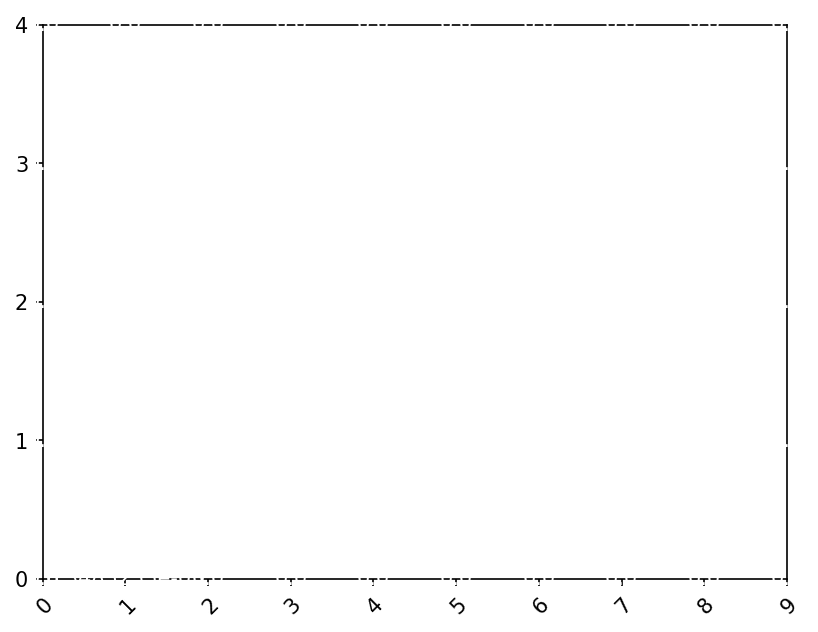

In [120]:
nucleotides = BASE_TO_COLUMN.keys()
positions = np.arange(1, 7814+1)[:10]

max_scores = np.squeeze(np.max(scores, axis=0))

fig, ax = plt.subplots()
# im = ax.imshow(max_scores)

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(positions)))
ax.set_yticks(np.arange(len(nucleotides)))

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(len(nucleotides)):
    for j in range(len(positions)):
        text = ax.text(j, i, max_scores[i, j],
                       ha="center", va="center", color="w")

In [236]:
output_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC"
X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz')).todense()
X_h37rv.shape

(1, 5, 7814, 1)

In [237]:
# check that the base to column indexing is correct
for idx in range(X_h37rv.shape[2]):
    
    pos = rif_rpoBC_df.loc[idx, "Pos"]
    ref = rpoBC_seqDF.loc["MT_H37Rv", pos]
    
    if not BASE_TO_COLUMN[ref] == np.where(np.squeeze(X_h37rv)[:, idx]==1)[0][0]:
        print(idx)

In [239]:
search_df

,mutation,MIC_pred,genome_index,WHO_genome_index,confidence,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,REF_len,ALT_len,saliency_score,dataset
10,rpoB_p.Gln432His,-1.063436,761102,761102,2) Assoc w R - Interim,761102,rpoB,p.Gln432His,A,T,rpoBC,2.071347,0.000000,0.001046,1.0,0.0,1,1,2.071347,1
14,rpoB_p.His445Asn,-1.661120,761139,761139,1) Assoc w R,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.000000,0.103309,1.0,0.0,1,1,3.437077,1
29,rpoB_p.Asp435Ala,-0.963358,761110,761110,2) Assoc w R - Interim,761110,rpoB,p.Asp435Ala,A,C,rpoBC,4.191139,0.000000,0.223620,1.0,0.0,1,1,4.191139,1
33,rpoB_p.Asp435His,-1.884073,761109,761109,2) Assoc w R - Interim,761109,rpoB,p.Asp435His,G,C,rpoBC,2.973908,-0.722329,0.037628,1.0,1.0,1,1,2.973908,1
47,rpoB_p.Leu430Arg,-1.703787,761095,761095,2) Assoc w R - Interim,761095,rpoB,p.Leu430Arg,T,G,rpoBC,2.659062,0.000000,0.015638,1.0,0.0,1,1,2.659062,1
49,rpoB_p.Leu452Gln,-1.203364,761161,761161,2) Assoc w R - Interim,761161,rpoB,p.Leu452Gln,T,A,rpoBC,2.145033,0.000000,0.017396,1.0,0.0,1,1,2.145033,0


In [248]:
rpoB_ALL_VCF.query("POS==761139").sort_values("mutation")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
16,RIF,761139,1) Assoc w R,rpoB_p.His445Asn,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
18,RIF,761139,1) Assoc w R,rpoB_p.His445Asp,761139,rpoB,p.His445Asp,C,G,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
19,RIF,761139,1) Assoc w R,rpoB_p.His445Cys,761139,rpoB,p.His445Cys,C,T,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
21,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Gly,761139,rpoB,p.His445Gly,C,G,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
23,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Phe,761139,rpoB,p.His445Phe,C,T,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
20,RIF,761139,1) Assoc w R,rpoB_p.His445Ser,761139,rpoB,p.His445Ser,C,A,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
22,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Thr,761139,rpoB,p.His445Thr,C,A,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
17,RIF,761139,1) Assoc w R,rpoB_p.His445Tyr,761139,rpoB,p.His445Tyr,C,T,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1


In [252]:
rpoB_ALL.query("mutation=='rpoB_p.His445Ser'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
20,RIF,761139,1) Assoc w R,rpoB_p.His445Ser,761139,rpoB,p.His445Ser,C,A,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
50,RIF,761140,1) Assoc w R,rpoB_p.His445Ser,761140,rpoB,p.His445Ser,A,G,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


In [253]:
rpoB_ALL.query("mutation=='rpoB_p.His445Thr'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
22,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Thr,761139,rpoB,p.His445Thr,C,A,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
53,RIF,761140,2) Assoc w R - Interim,rpoB_p.His445Thr,761140,rpoB,p.His445Thr,A,C,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


In [254]:
rpoB_ALL.query("mutation=='rpoB_p.His445Cys'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
19,RIF,761139,1) Assoc w R,rpoB_p.His445Cys,761139,rpoB,p.His445Cys,C,T,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
49,RIF,761140,1) Assoc w R,rpoB_p.His445Cys,761140,rpoB,p.His445Cys,A,G,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


In [255]:
rpoB_ALL.query("mutation=='rpoB_p.His445Gly'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
21,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Gly,761139,rpoB,p.His445Gly,C,G,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
52,RIF,761140,2) Assoc w R - Interim,rpoB_p.His445Gly,761140,rpoB,p.His445Gly,A,G,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


            mutation  MIC_pred ALT  saliency
14  rpoB_p.His445Asn -1.661120   A  0.000000
20  rpoB_p.His445Thr  0.403495   A  0.000000
18  rpoB_p.His445Ser  0.857502   A  0.000000
19  rpoB_p.His445Gly  1.638188   G  1.461783
21  rpoB_p.His445Phe  1.679750   T  1.677972
17  rpoB_p.His445Cys  1.761852   T  1.677972
16  rpoB_p.His445Asp  1.784891   G  1.461783
15  rpoB_p.His445Tyr  1.877036   T  1.677972


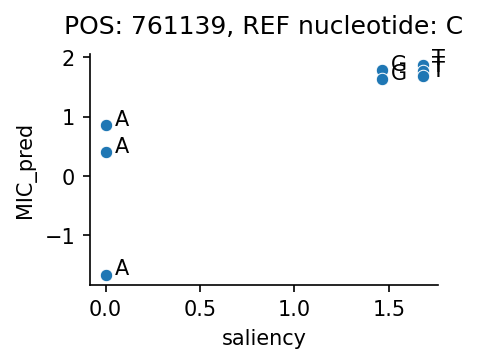

            mutation  MIC_pred ALT  saliency
29  rpoB_p.Asp435Ala -0.963358   C  0.000000
30  rpoB_p.Asp435Gly -0.617019   G  0.000000
31  rpoB_p.Asp435Leu  1.278635   T  1.948339
28  rpoB_p.Asp435Phe  1.684420   T  1.948339
27  rpoB_p.Asp435Val  1.743449   T  1.948339


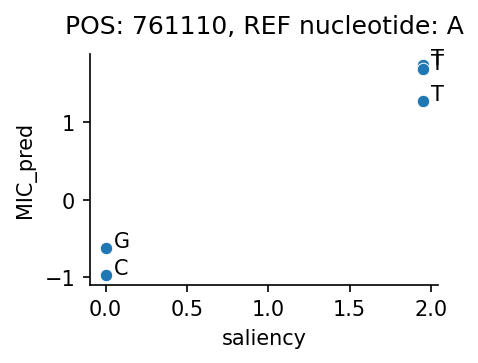

            mutation  MIC_pred ALT  saliency
33  rpoB_p.Asp435His -1.884073   C  0.000000
32  rpoB_p.Asp435Tyr  0.021469   T  1.823904


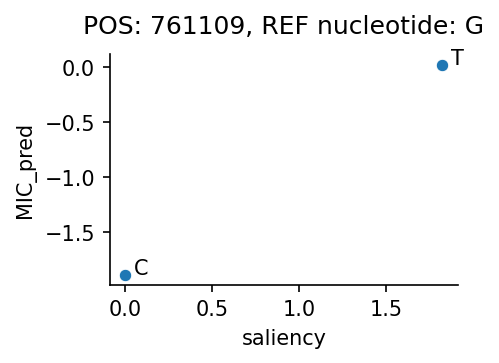

            mutation  MIC_pred ALT  saliency
47  rpoB_p.Leu430Arg -1.703787   G  0.135575
46  rpoB_p.Leu430Pro -0.011871   C  1.299761


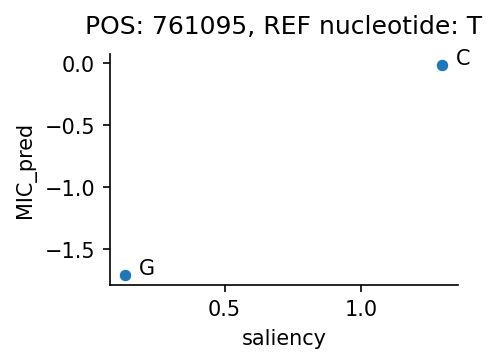

            mutation  MIC_pred ALT  saliency
49  rpoB_p.Leu452Gln -1.203364   A  0.000000
48  rpoB_p.Leu452Pro  0.146495   C  0.848814


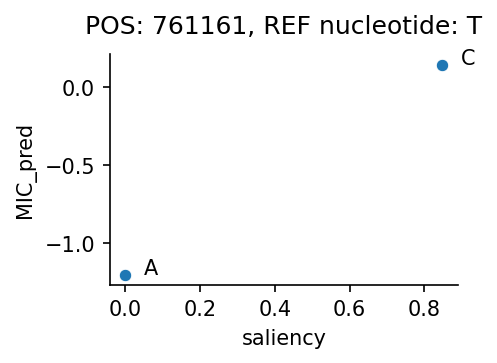

In [242]:
for pos in search_df.POS.unique():
    
    # this one has indels, skip for simplicity rn
    if pos != 761102:
        plot_nuc_scores_single_pos(pos)